# BESS Dispatch Analysis

This notebook runs the BESS (Battery Energy Storage System) strategy over 2018 GB market data and analyses dispatch behaviour across four dimensions:

1. **Price & Dispatch Overlay** — DA price curve vs. MW dispatch decisions for a sample day
2. **State of Charge Tracker** — SOC evolution across the full backtest period
3. **Rebalancing Impact** — DA-committed schedule vs. final executed dispatch
4. **PnL Waterfall** — Decomposition of net PnL into DA revenue, intraday gains, imbalance costs, and degradation

The strategy uses LP optimisation (PuLP/HiGHS) for Day-Ahead scheduling and a three-rule intraday engine for real-time adjustments.

In [15]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.bess.bess_asset import BESSAsset
from src.bess.da_optimizer import optimize_da_schedule
from src.bess.intraday_manager import run_intraday_session
from src.data.download import fetch_day_ahead_price, fetch_market_index_price, fetch_imbalance_price
from src.data.preprocess import process_day_ahead_price, process_market_index_price, process_imbalance_price
from src.utils.config import load_config

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

asset_dir = Path("assets")
asset_dir.mkdir(exist_ok=True)

config = load_config(REPO_ROOT / "configs" / "config.yaml")
BESS_CFG = config["bess"]

## Data Loading & BESS Backtest

Load DA, MID, and imbalance prices, resample to hourly, then run the BESS pipeline day-by-day — storing both the daily PnL summary and the per-hour dispatch log for plotting.

In [16]:
# Fetch and preprocess prices
da_processed = process_day_ahead_price(fetch_day_ahead_price())
mid_processed = process_market_index_price(fetch_market_index_price())
imb_processed = process_imbalance_price(fetch_imbalance_price())

# Resample to hourly and join
prices = (
    da_processed.resample("1h").mean()
    .join(mid_processed.resample("1h").mean())
    .join(imb_processed[["system_buy_price"]].resample("1h").mean())
    .dropna()
)

# Run BESS day-by-day
daily_results = []
all_dispatch_logs = []
all_da_schedules = []

for date, day_df in prices.groupby(prices.index.date):
    if len(day_df) != 24:
        continue

    asset = BESSAsset(**BESS_CFG)
    da_prices = day_df["day_ahead_price"].tolist()
    schedule = optimize_da_schedule(da_prices, asset)

    # Reset asset for intraday session
    asset.reset()
    result = run_intraday_session(
        da_schedule=schedule,
        da_prices=da_prices,
        mid_prices=day_df["mid_price"].tolist(),
        imbalance_prices=day_df["system_buy_price"].tolist(),
        asset=asset,
        config=BESS_CFG,
    )

    daily_results.append({
        "date": pd.Timestamp(date),
        "da_revenue": result["da_revenue"],
        "intraday_pnl": result["intraday_pnl"],
        "imbalance_pnl": result["imbalance_pnl"],
        "degradation_cost": result["total_degradation_cost"],
        "net_pnl": result["net_pnl"],
    })

    # Store per-hour dispatch log with timestamps
    for entry in result["dispatch_log"]:
        entry["date"] = date
        entry["hour"] = entry["period"]
        entry["timestamp"] = day_df.index[entry["period"]]
    all_dispatch_logs.extend(result["dispatch_log"])

    # Store DA schedule for rebalancing comparison
    for h, mw in enumerate(schedule):
        all_da_schedules.append({
            "date": date,
            "hour": h,
            "timestamp": day_df.index[h],
            "da_mw": mw,
        })

results_df = pd.DataFrame(daily_results)
dispatch_df = pd.DataFrame(all_dispatch_logs)
da_sched_df = pd.DataFrame(all_da_schedules)

print(f"Backtest complete: {len(results_df)} days")
print(f"Total net PnL: £{results_df['net_pnl'].sum():,.0f}")
print(f"Mean daily PnL: £{results_df['net_pnl'].mean():,.0f}")

Backtest complete: 344 days
Total net PnL: £1,080,068
Mean daily PnL: £3,140


---
## 1. Price & Dispatch Overlay

DA price curve (£/MWh) overlaid with the MW dispatch schedule for a representative high-spread day. Positive MW = discharge (selling into high prices), negative MW = charge (buying at low prices). The LP optimizer should charge overnight and discharge during the evening peak.

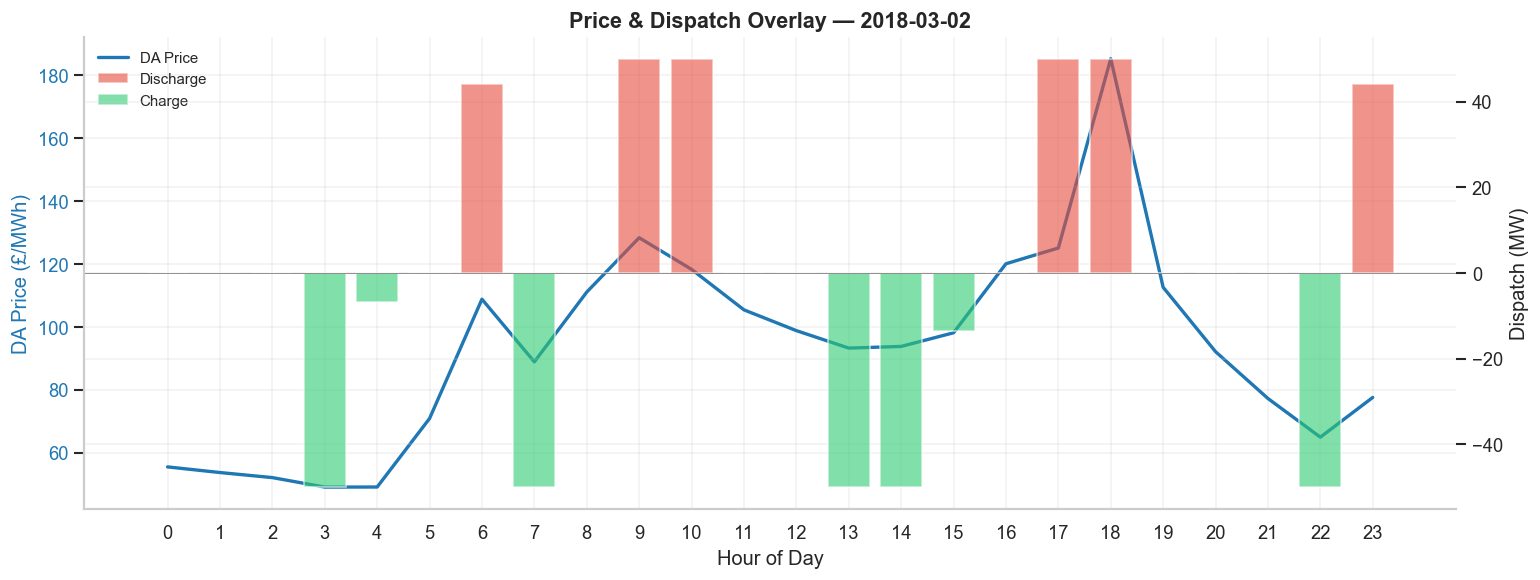

In [17]:
# Pick the backtest day with the highest DA price spread for visual clarity
valid_dates = set(da_sched_df["date"].unique())
mask = np.array([d in valid_dates for d in prices.index.date])
valid_prices = prices[mask]
daily_spread = valid_prices.groupby(valid_prices.index.date)["day_ahead_price"].apply(lambda x: x.max() - x.min())
sample_date = daily_spread.idxmax()

day_prices = prices.loc[prices.index.date == sample_date]
day_sched = da_sched_df[da_sched_df["date"] == sample_date]
hours = np.arange(24)

fig, ax1 = plt.subplots(figsize=(13, 5))

# DA price on the left axis
color_price = "#1f77b4"
ax1.plot(hours, day_prices["day_ahead_price"].values, color=color_price, linewidth=2, label="DA Price")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("DA Price (£/MWh)", color=color_price)
ax1.tick_params(axis="y", labelcolor=color_price)

# Dispatch on the right axis
ax2 = ax1.twinx()
color_charge = "#2ecc71"
color_discharge = "#e74c3c"
da_mw = day_sched["da_mw"].values
colors = [color_discharge if mw > 0 else color_charge for mw in da_mw]
ax2.bar(hours, da_mw, color=colors, alpha=0.6, width=0.8, label="Dispatch MW")
ax2.set_ylabel("Dispatch (MW)")
ax2.axhline(0, color="grey", linewidth=0.5)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
from matplotlib.patches import Patch
legend_elements = lines1 + [Patch(facecolor=color_discharge, alpha=0.6, label="Discharge"),
                            Patch(facecolor=color_charge, alpha=0.6, label="Charge")]
ax1.legend(handles=legend_elements, loc="upper left", frameon=False, fontsize=9)

ax1.set_title(f"Price & Dispatch Overlay — {sample_date}", fontsize=13, fontweight="bold")
ax1.set_xticks(hours)
plt.tight_layout()
plt.savefig(asset_dir / "bess_price_dispatch_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. State of Charge (SOC) Tracker

End-of-day SOC for every day in the backtest. Because the asset resets to `initial_soc_pct` (50%) at the start of each day, this chart shows how deeply the battery is cycled within each day. Days ending well below 50% indicate net discharge; days ending above indicate the optimizer found more value in charging.

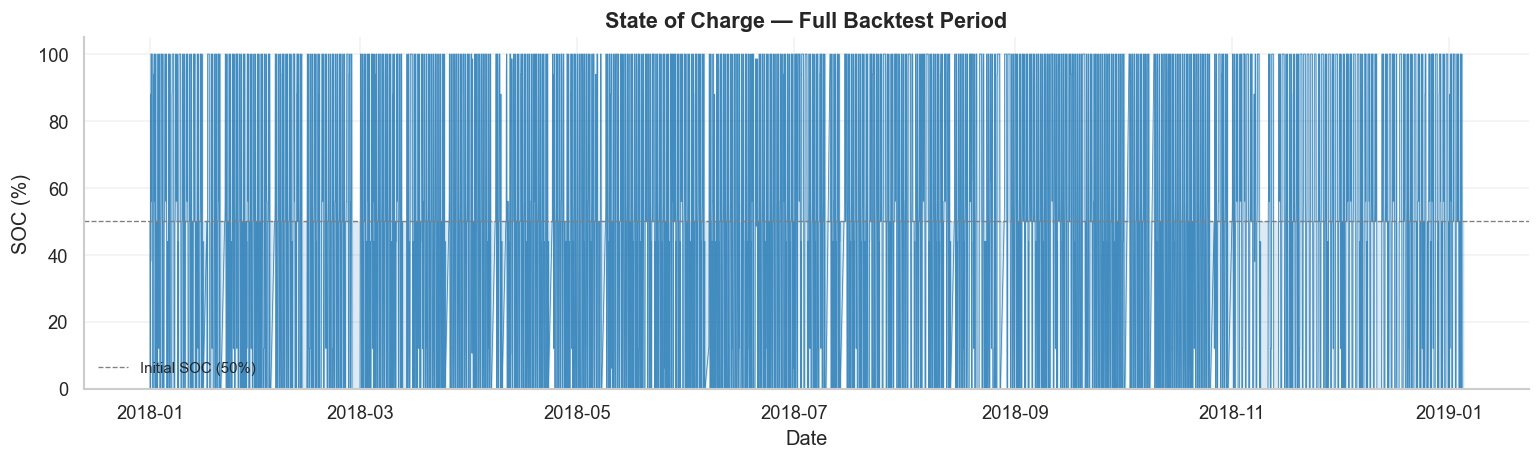

In [18]:
# SOC at the end of every hour across the full backtest
dispatch_df["timestamp"] = pd.to_datetime(dispatch_df["timestamp"])
soc_ts = dispatch_df.set_index("timestamp")["soc_after"].sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(soc_ts.index, soc_ts.values * 100, linewidth=0.5, color="#1f77b4", alpha=0.8)
ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, label="Initial SOC (50%)")
ax.fill_between(soc_ts.index, soc_ts.values * 100, 50, alpha=0.15, color="#1f77b4")
ax.set_title("State of Charge — Full Backtest Period", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("SOC (%)")
ax.set_ylim(0, 105)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(asset_dir / "bess_soc_tracker.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Rebalancing Impact — DA Schedule vs. Final Dispatch

Compares the LP-committed DA schedule with the actual dispatch (after intraday rebalancing) for the same sample day. The gap between the two series shows where the intraday rules engine adjusted volume — either to correct SOC drift or to exploit a MID spread improvement.

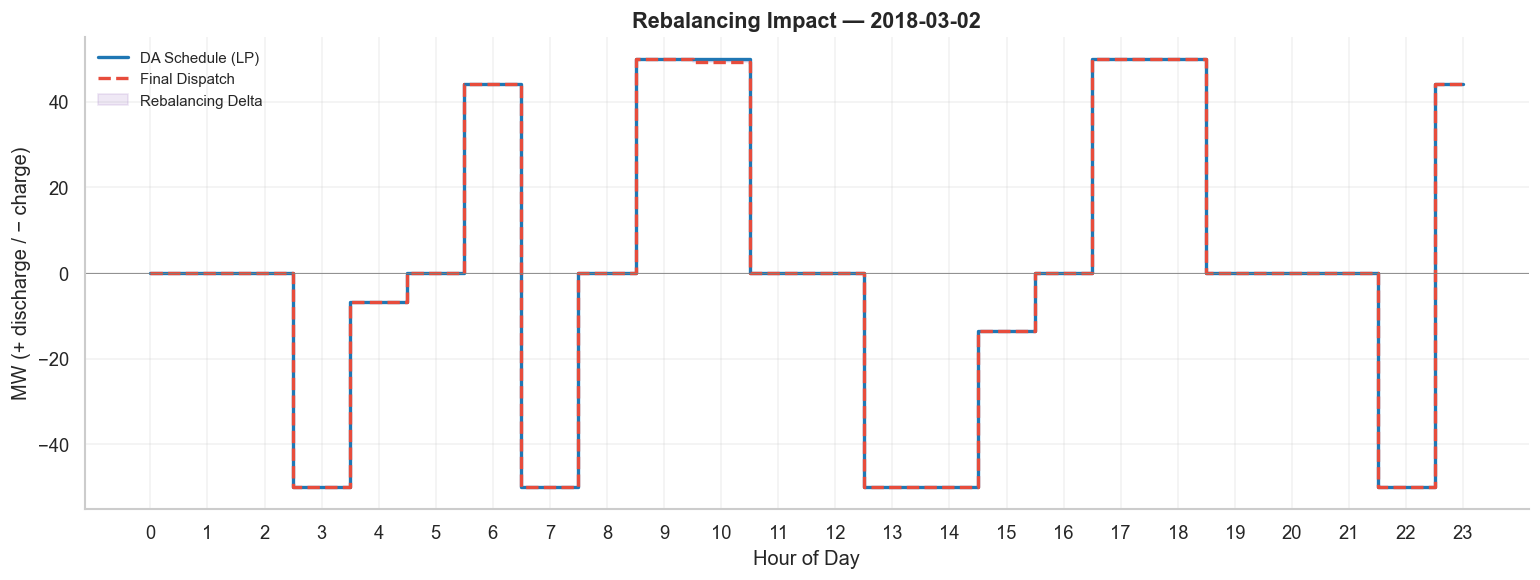

In [19]:
# Actual dispatch for the sample day from dispatch log
day_dispatch = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")

# Signed actual MW: positive for discharge, negative for charge
actual_mw = []
for _, row in day_dispatch.iterrows():
    if row["action"] == "discharge":
        actual_mw.append(row["mw"])
    elif row["action"] == "charge":
        actual_mw.append(-row["mw"])
    else:
        actual_mw.append(0.0)
actual_mw = np.array(actual_mw)

fig, ax = plt.subplots(figsize=(13, 5))

ax.step(hours, da_mw, where="mid", linewidth=2, color="#1f77b4", label="DA Schedule (LP)")
ax.step(hours, actual_mw, where="mid", linewidth=2, color="#e74c3c", linestyle="--", label="Final Dispatch")

# Shade the difference
ax.fill_between(hours, da_mw, actual_mw, alpha=0.15, color="#9467bd", step="mid", label="Rebalancing Delta")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MW (+ discharge / − charge)")
ax.set_title(f"Rebalancing Impact — {sample_date}", fontsize=13, fontweight="bold")
ax.set_xticks(hours)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(asset_dir / "bess_rebalancing_impact.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. PnL Waterfall

Stacked decomposition of total net PnL into its four components:

- **DA Revenue** — revenue from committed Day-Ahead positions
- **Intraday PnL** — gains/losses from rebalancing trades at MID
- **Imbalance PnL** — settlement costs/credits for undelivered volume
- **Degradation Cost** — throughput-based battery wear cost (subtracted)

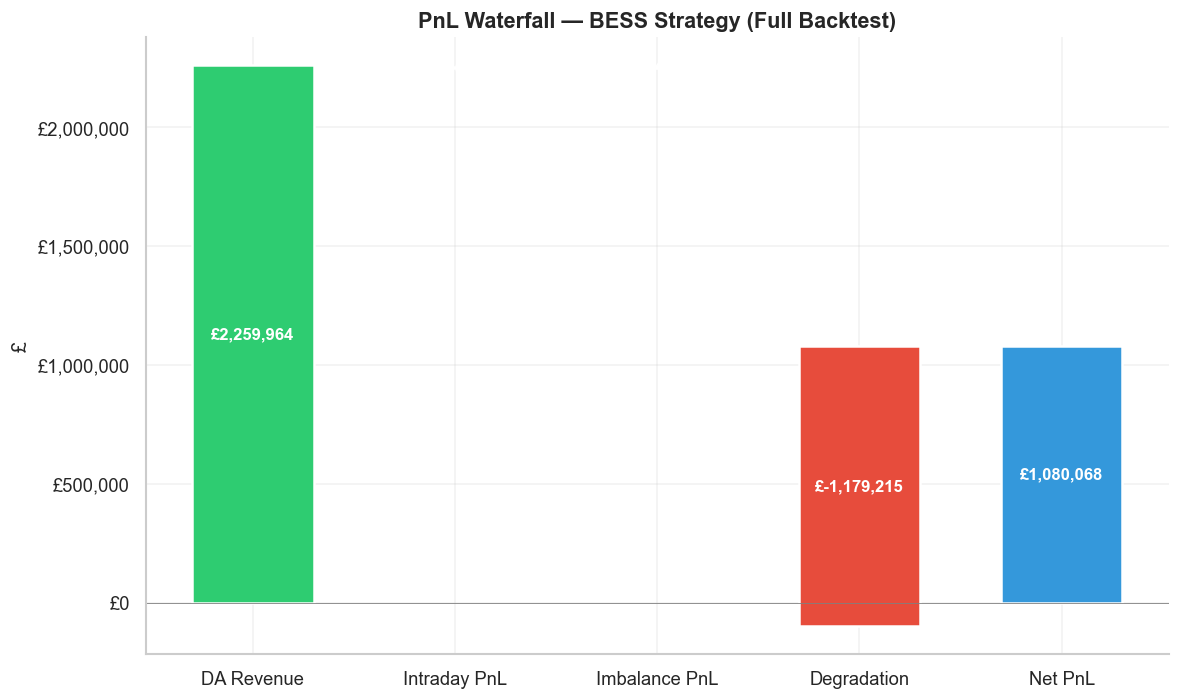

In [20]:
components = {
    "DA Revenue": results_df["da_revenue"].sum(),
    "Intraday PnL": results_df["intraday_pnl"].sum(),
    "Imbalance PnL": results_df["imbalance_pnl"].sum(),
    "Degradation": -results_df["degradation_cost"].sum(),
}
net = sum(components.values())

labels = list(components.keys()) + ["Net PnL"]
values = list(components.values()) + [net]

# Waterfall: running bottom positions
bottoms = []
running = 0.0
for v in list(components.values()):
    if v >= 0:
        bottoms.append(running)
        running += v
    else:
        running += v
        bottoms.append(running)
bottoms.append(0.0)

colors = []
for v in list(components.values()):
    colors.append("#2ecc71" if v >= 0 else "#e74c3c")
colors.append("#3498db")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, bottom=bottoms, color=colors, width=0.6, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, values):
    y = bar.get_y() + bar.get_height() / 2
    ax.text(bar.get_x() + bar.get_width() / 2, y, f"£{val:,.0f}",
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.set_ylabel("£")
ax.set_title("PnL Waterfall — BESS Strategy (Full Backtest)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.savefig(asset_dir / "bess_pnl_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Summary Metrics

In [21]:
avg_daily = results_df["net_pnl"].mean()
std_daily = results_df["net_pnl"].std(ddof=1)
sharpe = (avg_daily / std_daily) * np.sqrt(365) if std_daily > 0 else 0.0
cumulative = results_df["net_pnl"].cumsum()
max_dd = (cumulative - cumulative.cummax()).min()

throughput = results_df["degradation_cost"].sum() / BESS_CFG["degradation_cost_per_mwh"]
total_cycles = throughput / (2 * BESS_CFG["capacity_mwh"])

summary = pd.DataFrame({
    "Metric": [
        "Total DA Revenue", "Total Intraday PnL", "Total Imbalance PnL",
        "Total Degradation Cost", "Total Net PnL",
        "Mean Daily PnL", "Sharpe Ratio", "Max Drawdown",
        "Total Equivalent Cycles", "Days Traded",
    ],
    "Value": [
        f"£{results_df['da_revenue'].sum():,.0f}",
        f"£{results_df['intraday_pnl'].sum():,.0f}",
        f"£{results_df['imbalance_pnl'].sum():,.0f}",
        f"£{results_df['degradation_cost'].sum():,.0f}",
        f"£{results_df['net_pnl'].sum():,.0f}",
        f"£{avg_daily:,.0f}",
        f"{sharpe:.3f}",
        f"£{max_dd:,.0f}",
        f"{total_cycles:.1f}",
        f"{len(results_df)}",
    ],
}).set_index("Metric")

summary.style.set_properties(**{"text-align": "right"})

,Value
Metric,
Total DA Revenue,"£2,259,964"
Total Intraday PnL,"£-6,095"
Total Imbalance PnL,"£5,414"
Total Degradation Cost,"£1,179,215"
Total Net PnL,"£1,080,068"
Mean Daily PnL,"£3,140"
Sharpe Ratio,42.260
Max Drawdown,£0
Total Equivalent Cycles,693.7
